# Patient Health Records – Data Preprocessing
### Data Analyst Project | Missing Values + Outlier Handling

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from scipy import stats
from scipy.stats.mstats import winsorize

print("Libraries loaded")

Libraries loaded


## Step 1 – Generate Dataset (550 rows)

In [2]:
np.random.seed(42)
n = 550

patient_id = [f'P{str(i).zfill(4)}' for i in range(1, n+1)]

# Age – integer, some missing
age = np.random.randint(20, 81, n).astype(float)
age[np.random.choice(n, 30, replace=False)] = np.nan

# Gender – Male/Female, some missing
gender = np.random.choice(['Male', 'Female'], n).astype(object)
gender[np.random.choice(n, 35, replace=False)] = np.nan

# Region – 4 categories, some missing
region = np.random.choice(['North', 'South', 'East', 'West'], n).astype(object)
region[np.random.choice(n, 40, replace=False)] = np.nan

# BMI – normal range with some outliers and missing
bmi = np.round(np.random.normal(26.5, 4.5, n), 2)
bmi[np.random.choice(n, 12, replace=False)] = np.random.choice([2.1, 3.5, 78.0, 85.0], 12, replace=True)
bmi[np.random.choice(n, 45, replace=False)] = np.nan

# Blood Pressure – some very high outlier values
bp = np.round(np.random.normal(118, 13, n), 1)
bp[np.random.choice(n, 18, replace=False)] = np.random.choice([210, 225, 240, 260], 18, replace=True)

# Cholesterol – outliers + missing
cholesterol = np.round(np.random.normal(195, 28, n), 1)
cholesterol[np.random.choice(n, 15, replace=False)] = np.random.choice([8, 12, 510, 560], 15, replace=True)
cholesterol[np.random.choice(n, 40, replace=False)] = np.nan

# Glucose – high spikes + missing
glucose = np.round(np.random.normal(95, 17, n), 1)
glucose[np.random.choice(n, 18, replace=False)] = np.random.choice([420, 480, 530, 590], 18, replace=True)
glucose[np.random.choice(n, 38, replace=False)] = np.nan

# Disease risk – binary target, no missing
disease_risk = np.random.choice([0, 1], n, p=[0.60, 0.40])

df = pd.DataFrame({
    'patient_id':     patient_id,
    'age':            age,
    'gender':         gender,
    'region':         region,
    'bmi':            bmi,
    'blood_pressure': bp,
    'cholesterol':    cholesterol,
    'glucose':        glucose,
    'disease_risk':   disease_risk
})

print(f"Dataset shape: {df.shape}")
df.head(10)

Dataset shape: (550, 9)


,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,P0001,58.0,Female,East,30.04,95.9,179.2,71.3,0
1,P0002,71.0,Female,West,22.49,112.0,206.8,83.0,1
2,P0003,48.0,Female,North,21.72,110.0,204.3,90.5,1
3,P0004,34.0,Male,West,27.12,131.7,199.0,67.9,1
4,P0005,62.0,Female,South,25.34,104.8,163.2,NaN,1
5,P0006,27.0,Male,North,30.67,108.1,NaN,106.1,0
6,P0007,80.0,Female,South,28.69,113.0,257.2,119.3,0
7,P0008,40.0,Male,West,29.00,110.5,195.2,87.9,0
8,P0009,58.0,Female,West,NaN,135.8,165.7,107.9,0
9,P0010,77.0,NaN,South,NaN,103.2,NaN,62.5,1


In [3]:
print(df.info())
print()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   patient_id      550 non-null    object 
 1   age             520 non-null    float64
 2   gender          515 non-null    object 
 3   region          510 non-null    object 
 4   bmi             505 non-null    float64
 5   blood_pressure  550 non-null    float64
 6   cholesterol     510 non-null    float64
 7   glucose         512 non-null    float64
 8   disease_risk    550 non-null    int64  
dtypes: float64(5), int64(1), object(3)
memory usage: 38.8+ KB
None



,age,bmi,blood_pressure,cholesterol,glucose,disease_risk
count,520.000000,505.000000,550.000000,510.000000,512.000000,550.000000
mean,50.842308,26.918040,121.413273,196.762745,107.017187,0.385455
std,17.623283,7.106704,24.978160,50.359874,69.560499,0.487146
min,20.000000,2.100000,74.800000,8.000000,50.400000,0.000000
25%,37.000000,23.540000,109.200000,176.700000,83.800000,0.000000
50%,51.000000,26.850000,117.500000,192.400000,95.100000,0.000000
75%,66.000000,30.040000,127.450000,213.900000,107.400000,1.000000
max,80.000000,85.000000,260.000000,560.000000,590.000000,1.000000


---
# Part A – Handling Missing Values

             Missing Count  Missing %
bmi                     45       8.18
region                  40       7.27
cholesterol             40       7.27
glucose                 38       6.91
gender                  35       6.36
age                     30       5.45


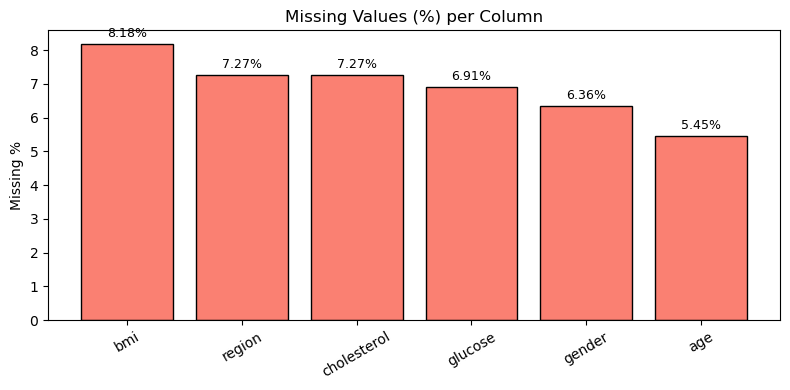

In [4]:
missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(2)

report = pd.DataFrame({'Missing Count': missing, 'Missing %': pct})
report = report[report['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(report)

# bar chart
plt.figure(figsize=(8, 4))
plt.bar(report.index, report['Missing %'], color='salmon', edgecolor='black')
plt.title('Missing Values (%) per Column')
plt.ylabel('Missing %')
plt.xticks(rotation=30)
for i, v in enumerate(report['Missing %']):
    plt.text(i, v + 0.2, f'{v}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

### Task 2a – Simple Imputer (Numerical) – BMI with Mean and Median

Rows where BMI was missing (first 10):
    patient_id  bmi  bmi_mean  bmi_median
8        P0009  NaN  26.91804       26.85
9        P0010  NaN  26.91804       26.85
23       P0024  NaN  26.91804       26.85
33       P0034  NaN  26.91804       26.85
52       P0053  NaN  26.91804       26.85
57       P0058  NaN  26.91804       26.85
66       P0067  NaN  26.91804       26.85
77       P0078  NaN  26.91804       26.85
104      P0105  NaN  26.91804       26.85
130      P0131  NaN  26.91804       26.85


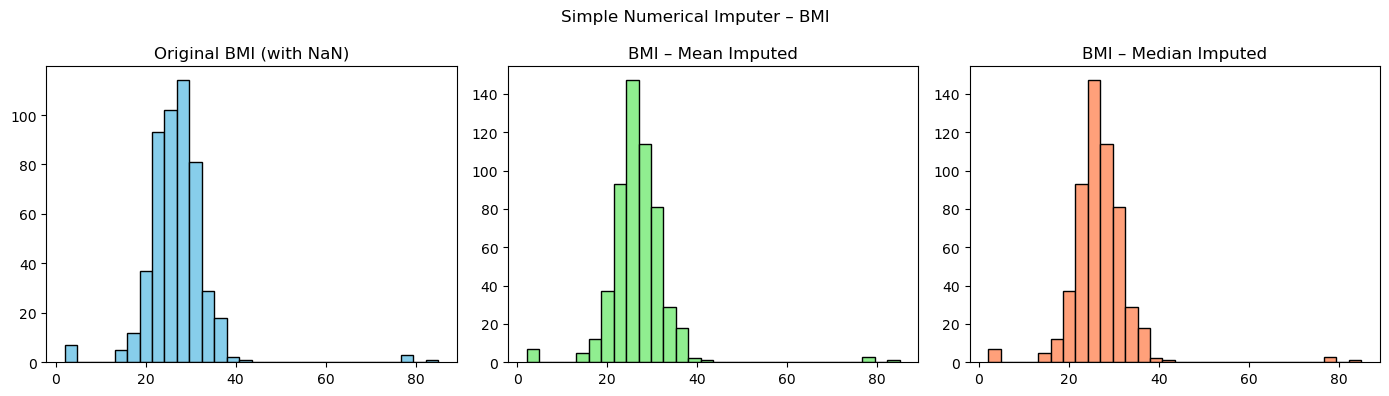

In [5]:
df_a = df.copy()

mean_imp   = SimpleImputer(strategy='mean')
median_imp = SimpleImputer(strategy='median')

df_a['bmi_mean']   = mean_imp.fit_transform(df_a[['bmi']])
df_a['bmi_median'] = median_imp.fit_transform(df_a[['bmi']])

# show rows that were missing
was_missing = df['bmi'].isnull()
print("Rows where BMI was missing (first 10):")
print(df_a[was_missing][['patient_id', 'bmi', 'bmi_mean', 'bmi_median']].head(10))

# distribution comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df['bmi'].dropna(), bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Original BMI (with NaN)')

axes[1].hist(df_a['bmi_mean'], bins=30, color='lightgreen', edgecolor='black')
axes[1].set_title('BMI – Mean Imputed')

axes[2].hist(df_a['bmi_median'], bins=30, color='lightsalmon', edgecolor='black')
axes[2].set_title('BMI – Median Imputed')

plt.suptitle('Simple Numerical Imputer – BMI')
plt.tight_layout()
plt.show()

### Task 2b – Simple Imputer (Categorical) – Region with Most Frequent

Most frequent region used: North
Missing before: 40
Missing after:  0


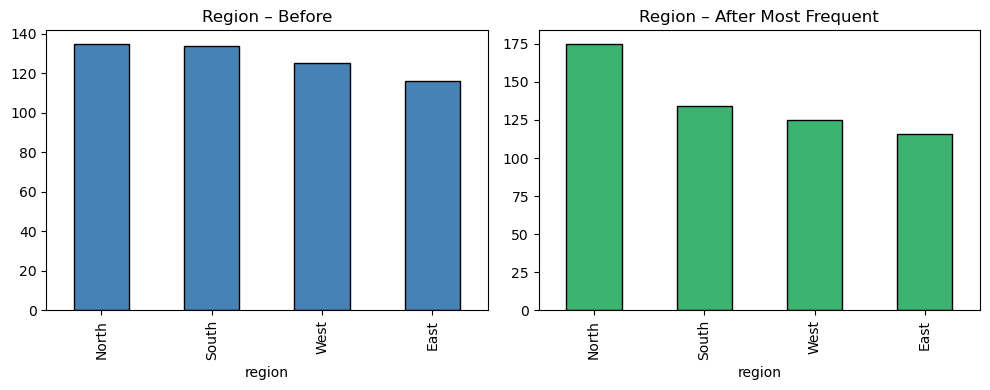

In [6]:
df_b = df.copy()

cat_imp = SimpleImputer(strategy='most_frequent')
df_b['region'] = cat_imp.fit_transform(df_b[['region']]).ravel()

print(f"Most frequent region used: {df['region'].mode()[0]}")
print(f"Missing before: {df['region'].isnull().sum()}")
print(f"Missing after:  {df_b['region'].isnull().sum()}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df['region'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Region – Before')

df_b['region'].value_counts().plot(kind='bar', ax=axes[1], color='mediumseagreen', edgecolor='black')
axes[1].set_title('Region – After Most Frequent')

plt.tight_layout()
plt.show()

### Task 2c – Most Frequent Imputation – Gender

Most frequent gender: Male
Missing before: 35
Missing after:  0


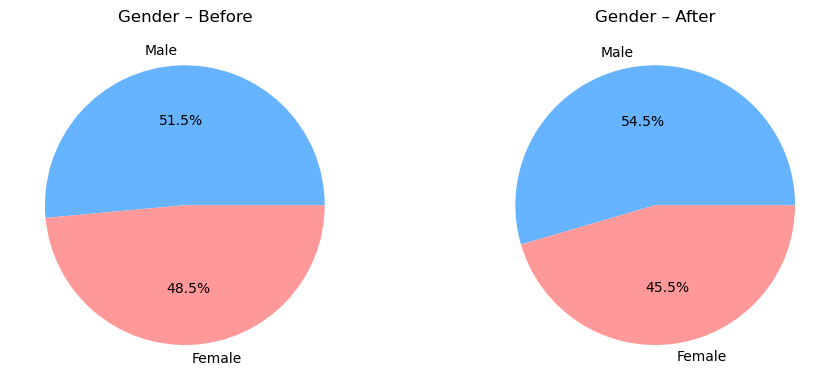

In [7]:
df_c = df.copy()

g_imp = SimpleImputer(strategy='most_frequent')
df_c['gender'] = g_imp.fit_transform(df_c[['gender']]).ravel()

print(f"Most frequent gender: {df['gender'].mode()[0]}")
print(f"Missing before: {df['gender'].isnull().sum()}")
print(f"Missing after:  {df_c['gender'].isnull().sum()}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df['gender'].value_counts().plot(kind='pie', ax=axes[0], autopct='%1.1f%%',
                                  colors=['#66b3ff', '#ff9999', '#cccccc'])
axes[0].set_title('Gender – Before')
axes[0].set_ylabel('')

df_c['gender'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                    colors=['#66b3ff', '#ff9999'])
axes[1].set_title('Gender – After')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### Task 2d – Missing Indicator + Random Sample Imputation

In [8]:
df_d = df.copy()

num_cols = ['age', 'bmi', 'cholesterol', 'glucose']

for col in num_cols:
    # create flag column (1 = was missing)
    df_d[col + '_flag'] = df_d[col].isnull().astype(int)
    
    # fill missing with random sample from existing values
    null_mask = df_d[col].isnull()
    existing  = df_d[col].dropna().values
    df_d.loc[null_mask, col] = np.random.choice(existing, size=null_mask.sum(), replace=True)

print("Flag columns (how many were missing per column):")
flag_cols = [c for c in df_d.columns if c.endswith('_flag')]
print(df_d[flag_cols].sum())

print()
print("Missing after imputation:")
print(df_d[num_cols].isnull().sum())

print()
print(df_d[['patient_id', 'bmi', 'bmi_flag', 'glucose', 'glucose_flag']].head(12))

Flag columns (how many were missing per column):
age_flag            30
bmi_flag            45
cholesterol_flag    40
glucose_flag        38
dtype: int64

Missing after imputation:
age            0
bmi            0
cholesterol    0
glucose        0
dtype: int64

   patient_id    bmi  bmi_flag  glucose  glucose_flag
0       P0001  30.04         0     71.3             0
1       P0002  22.49         0     83.0             0
2       P0003  21.72         0     90.5             0
3       P0004  27.12         0     67.9             0
4       P0005  25.34         0     68.1             1
5       P0006  30.67         0    106.1             0
6       P0007  28.69         0    119.3             0
7       P0008  29.00         0     87.9             0
8       P0009  27.79         1    107.9             0
9       P0010  19.98         1     62.5             0
10      P0011  22.73         0    106.2             0
11      P0012  29.25         0     81.3             0


### Task 2e – KNN Imputer

Missing after KNN:
age            0
bmi            0
cholesterol    0
glucose        0
dtype: int64


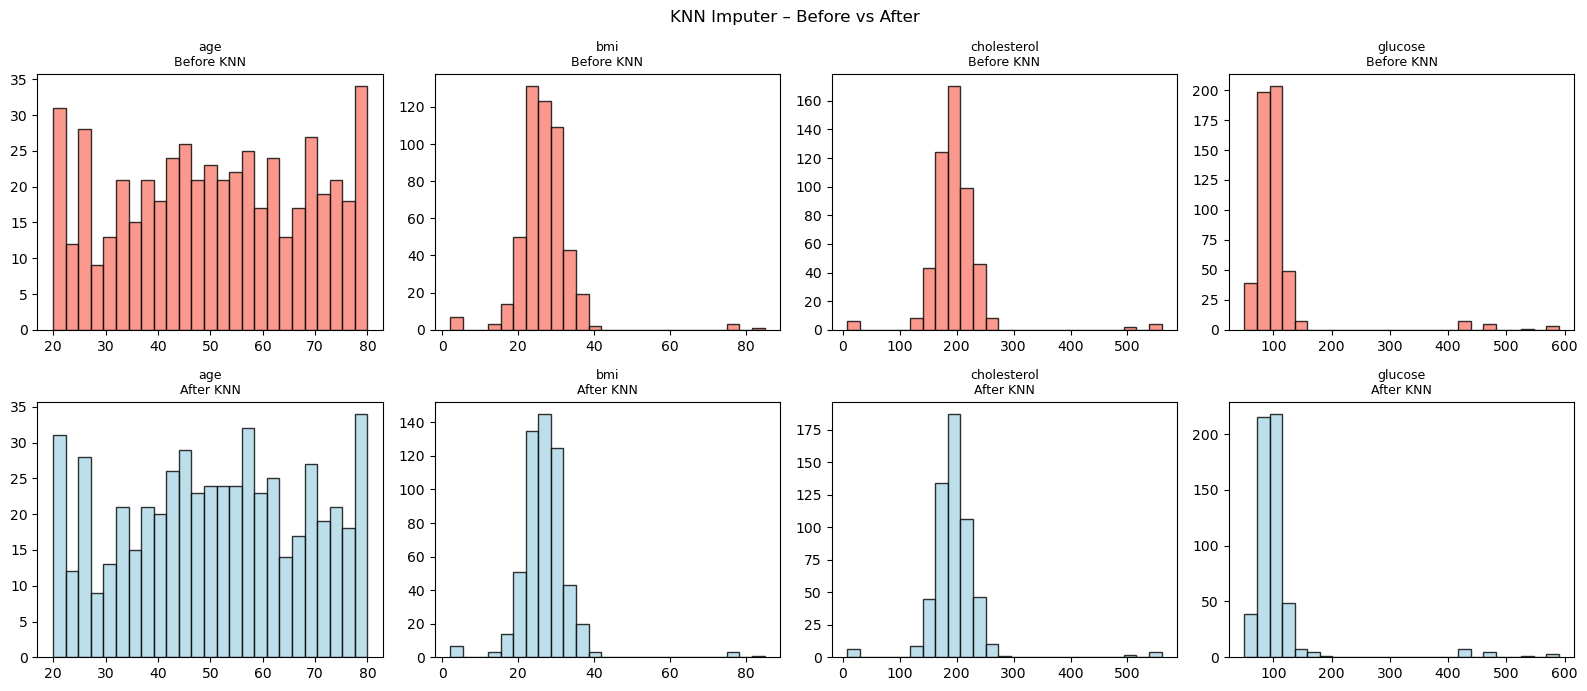

In [9]:
df_e = df.copy()

num_cols = ['age', 'bmi', 'cholesterol', 'glucose']

knn = KNNImputer(n_neighbors=5)
df_e[num_cols] = knn.fit_transform(df_e[num_cols])

print("Missing after KNN:")
print(df_e[num_cols].isnull().sum())

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for i, col in enumerate(num_cols):
    axes[0, i].hist(df[col].dropna(), bins=25, color='salmon', edgecolor='black', alpha=0.8)
    axes[0, i].set_title(f'{col}\nBefore KNN', fontsize=9)

    axes[1, i].hist(df_e[col], bins=25, color='lightblue', edgecolor='black', alpha=0.8)
    axes[1, i].set_title(f'{col}\nAfter KNN', fontsize=9)

plt.suptitle('KNN Imputer – Before vs After')
plt.tight_layout()
plt.show()

### Task 2f – MICE Algorithm (Iterative Imputer)

Missing after MICE:
age            0
bmi            0
cholesterol    0
glucose        0
dtype: int64

          age     bmi  cholesterol  glucose
count  550.00  550.00       550.00   550.00
mean    50.84   26.92       196.76   107.02
std     17.14    6.81        48.49    67.11
min     20.00    2.10         8.00    50.40
25%     38.00   23.89       178.42    85.05
50%     50.85   26.87       195.70    96.40
75%     65.00   29.54       211.65   107.02
max     80.00   85.00       560.00   590.00


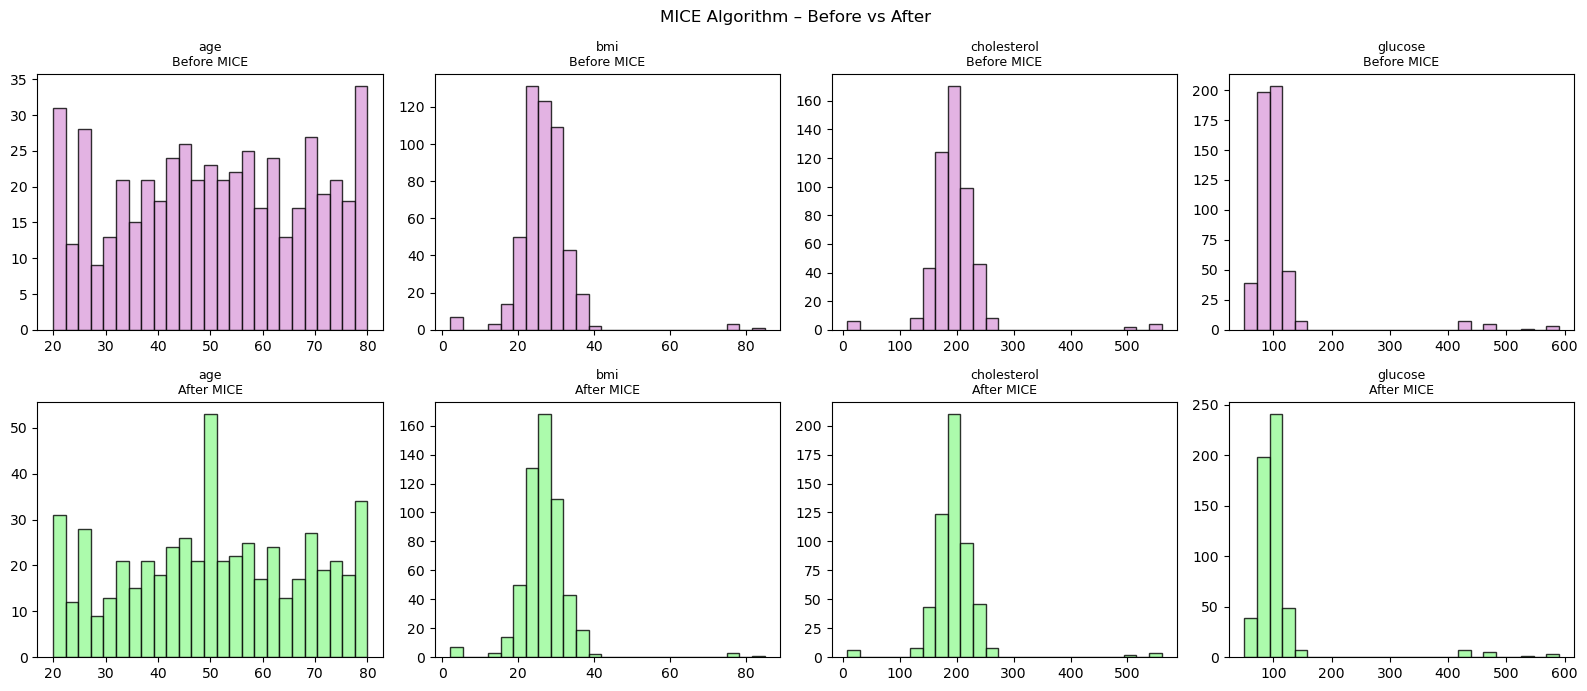

In [10]:
df_f = df.copy()

num_cols = ['age', 'bmi', 'cholesterol', 'glucose']

mice = IterativeImputer(max_iter=10, random_state=42)
df_f[num_cols] = mice.fit_transform(df_f[num_cols])

print("Missing after MICE:")
print(df_f[num_cols].isnull().sum())

print()
print(df_f[num_cols].describe().round(2))

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for i, col in enumerate(num_cols):
    axes[0, i].hist(df[col].dropna(), bins=25, color='plum', edgecolor='black', alpha=0.8)
    axes[0, i].set_title(f'{col}\nBefore MICE', fontsize=9)

    axes[1, i].hist(df_f[col], bins=25, color='palegreen', edgecolor='black', alpha=0.8)
    axes[1, i].set_title(f'{col}\nAfter MICE', fontsize=9)

plt.suptitle('MICE Algorithm – Before vs After')
plt.tight_layout()
plt.show()

---
# Part B – Handling Outliers

First we prepare a clean base (no NaN) using MICE + most frequent, then apply all 4 outlier methods.

### Base Dataset – No Missing Values

In [12]:
base = df_f.copy()

# fill remaining categoricals
for col in ['gender', 'region']:
    base[col] = base[col].fillna(base[col].mode()[0])

print("Missing values in base:")
print(base.isnull().sum())
print(f"Shape: {base.shape}")

Missing values in base:
patient_id        0
age               0
gender            0
region            0
bmi               0
blood_pressure    0
cholesterol       0
glucose           0
disease_risk      0
dtype: int64
Shape: (550, 9)


### Task 3a – Z-Score Method (Cholesterol & Glucose)

cholesterol – outliers found: 12
  values: [8.0, 8.0, 12.0, 12.0, 12.0, 12.0, 510.0, 510.0]
glucose – outliers found: 16
  values: [420.0, 420.0, 420.0, 420.0, 420.0, 420.0, 420.0, 480.0]

Rows before: 550  |  After removing outliers: 522


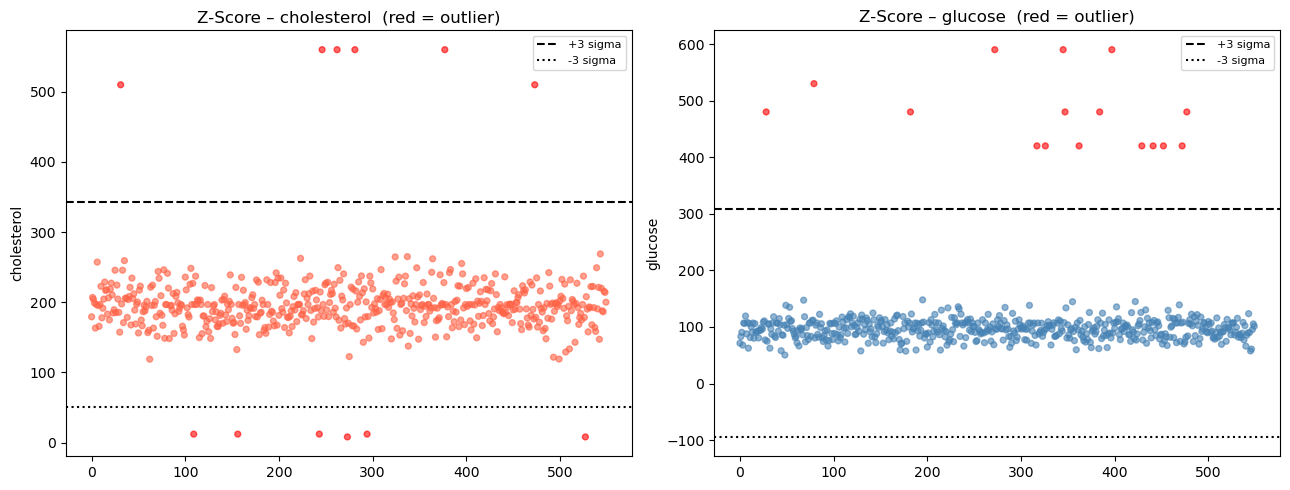

In [13]:
df_z = base.copy()

z_cols = ['cholesterol', 'glucose']

for col in z_cols:
    z = np.abs(stats.zscore(df_z[col]))
    outliers = (z > 3)
    print(f"{col} – outliers found: {outliers.sum()}")
    print(f"  values: {sorted(df_z.loc[outliers, col].tolist())[:8]}")
    df_z = df_z[~outliers]

print(f"\nRows before: {len(base)}  |  After removing outliers: {len(df_z)}")

# scatter plots showing outliers
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, color in zip(axes, z_cols, ['tomato', 'steelblue']):
    z_full = np.abs(stats.zscore(base[col]))
    colors = ['red' if v > 3 else color for v in z_full]
    ax.scatter(range(len(base)), base[col], c=colors, s=18, alpha=0.6)
    ax.axhline(base[col].mean() + 3*base[col].std(), color='black', linestyle='--', label='+3 sigma')
    ax.axhline(base[col].mean() - 3*base[col].std(), color='black', linestyle=':', label='-3 sigma')
    ax.set_title(f'Z-Score – {col}  (red = outlier)')
    ax.set_ylabel(col)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Task 3b – IQR Method (BMI & Blood Pressure)

bmi:
  Q1=23.89, Q3=29.54, IQR=5.65
  Lower fence=15.41, Upper fence=38.02
  Outliers found: 17
blood_pressure:
  Q1=109.20, Q3=127.70, IQR=18.50
  Lower fence=81.45, Upper fence=155.45
  Outliers found: 19

Rows before: 550  |  After: 514


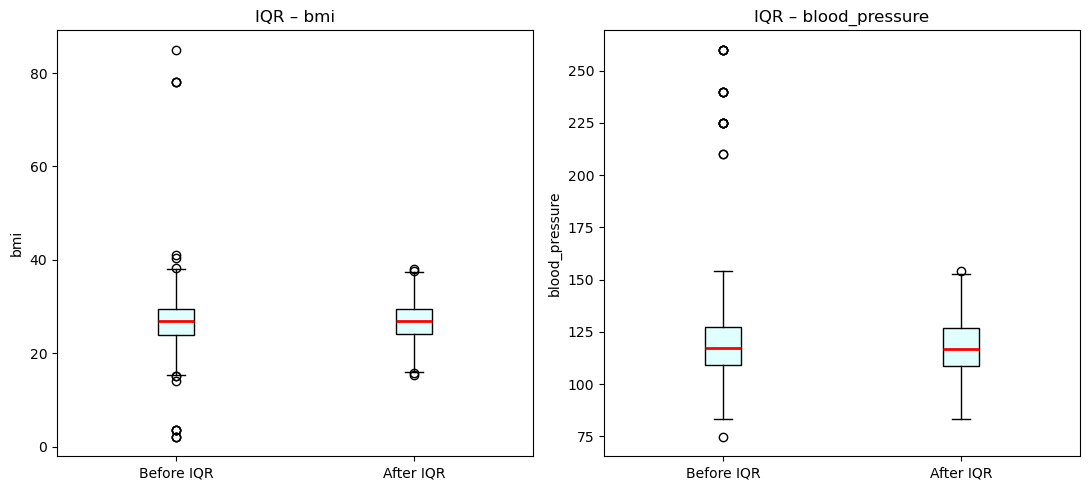

In [14]:
df_iqr = base.copy()

iqr_cols = ['bmi', 'blood_pressure']

for col in iqr_cols:
    Q1 = df_iqr[col].quantile(0.25)
    Q3 = df_iqr[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = (df_iqr[col] < lower) | (df_iqr[col] > upper)
    print(f"{col}:")
    print(f"  Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
    print(f"  Lower fence={lower:.2f}, Upper fence={upper:.2f}")
    print(f"  Outliers found: {outliers.sum()}")
    df_iqr = df_iqr[~outliers]

print(f"\nRows before: {len(base)}  |  After: {len(df_iqr)}")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, col in zip(axes, iqr_cols):
    ax.boxplot([base[col].dropna(), df_iqr[col].dropna()],
               labels=['Before IQR', 'After IQR'],
               patch_artist=True,
               boxprops=dict(facecolor='lightcyan'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(f'IQR – {col}')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

### Task 3c – Percentile Method (Cap at 1st and 99th percentile)

bmi:
  Before -> min=2.10, max=85.00
  After  -> min=3.50, max=39.39

blood_pressure:
  Before -> min=74.80, max=260.00
  After  -> min=89.10, max=240.00

cholesterol:
  Before -> min=8.00, max=560.00
  After  -> min=64.33, max=391.86

glucose:
  Before -> min=50.40, max=590.00
  After  -> min=59.25, max=480.00



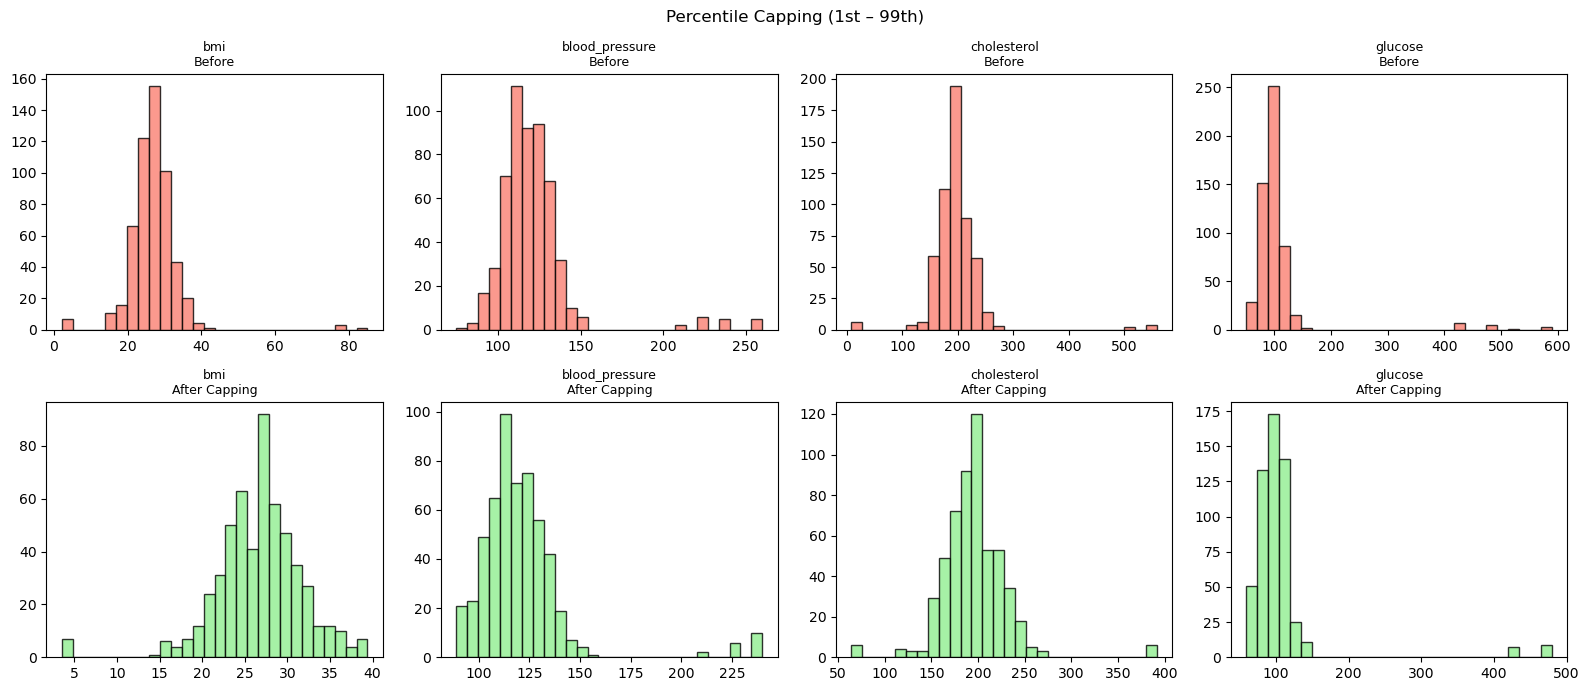

In [15]:
df_pct = base.copy()

pct_cols = ['bmi', 'blood_pressure', 'cholesterol', 'glucose']

for col in pct_cols:
    p1  = df_pct[col].quantile(0.01)
    p99 = df_pct[col].quantile(0.99)

    before_min = df_pct[col].min()
    before_max = df_pct[col].max()

    df_pct[col] = df_pct[col].clip(lower=p1, upper=p99)

    print(f"{col}:")
    print(f"  Before -> min={before_min:.2f}, max={before_max:.2f}")
    print(f"  After  -> min={df_pct[col].min():.2f}, max={df_pct[col].max():.2f}")
    print()

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for i, col in enumerate(pct_cols):
    axes[0, i].hist(base[col], bins=28, color='salmon', edgecolor='black', alpha=0.8)
    axes[0, i].set_title(f'{col}\nBefore', fontsize=9)

    axes[1, i].hist(df_pct[col], bins=28, color='lightgreen', edgecolor='black', alpha=0.8)
    axes[1, i].set_title(f'{col}\nAfter Capping', fontsize=9)

plt.suptitle('Percentile Capping (1st – 99th)')
plt.tight_layout()
plt.show()

### Task 4 – Winsorization (cap extreme values instead of removing rows)

bmi:
  Before -> min=2.10, max=85.00
  After  -> min=15.77, max=36.59

blood_pressure:
  Before -> min=74.80, max=260.00
  After  -> min=92.40, max=225.00

cholesterol:
  Before -> min=8.00, max=560.00
  After  -> min=132.50, max=259.30

glucose:
  Before -> min=50.40, max=590.00
  After  -> min=62.50, max=420.00



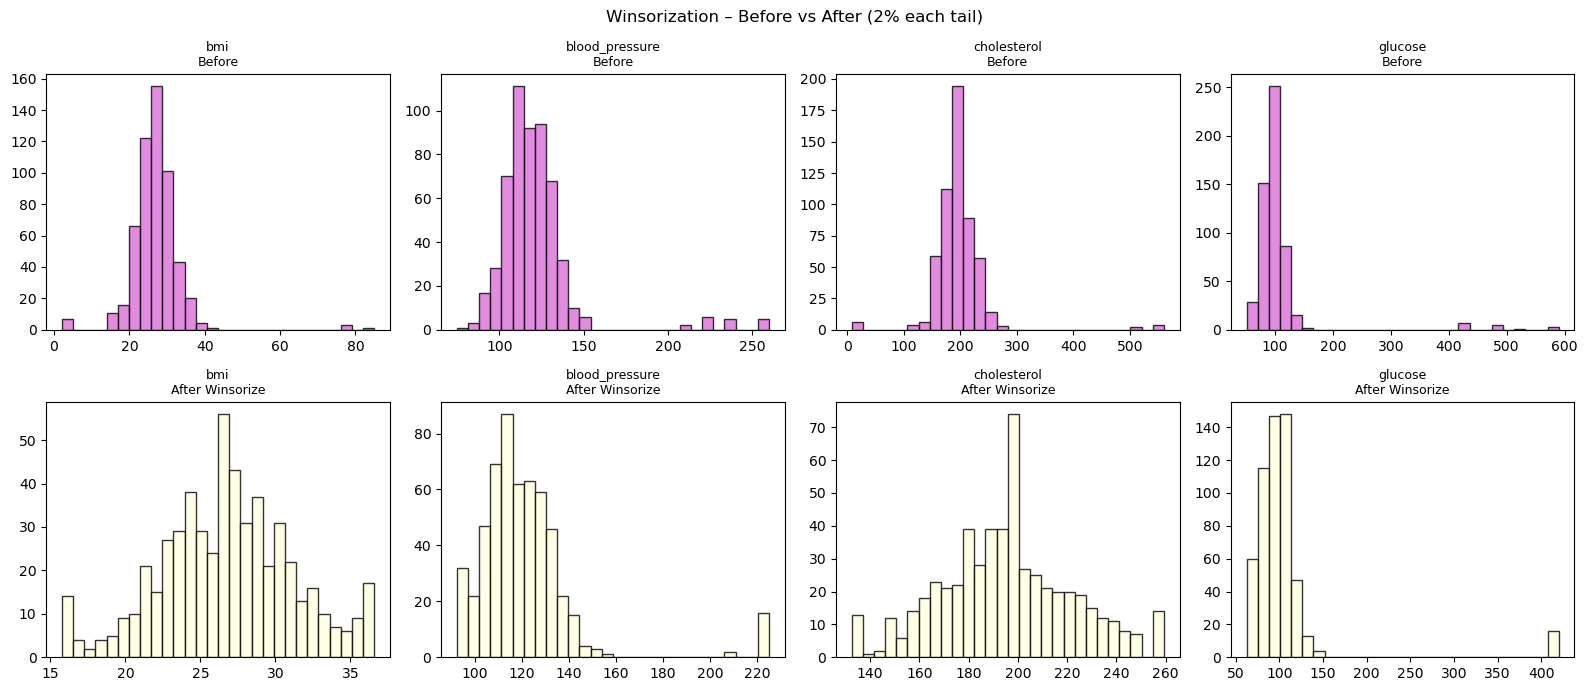

In [16]:
df_wins = base.copy()

wins_cols = ['bmi', 'blood_pressure', 'cholesterol', 'glucose']

for col in wins_cols:
    before_min = df_wins[col].min()
    before_max = df_wins[col].max()

    df_wins[col] = winsorize(df_wins[col], limits=[0.02, 0.02]).data

    print(f"{col}:")
    print(f"  Before -> min={before_min:.2f}, max={before_max:.2f}")
    print(f"  After  -> min={df_wins[col].min():.2f}, max={df_wins[col].max():.2f}")
    print()

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for i, col in enumerate(wins_cols):
    axes[0, i].hist(base[col], bins=28, color='orchid', edgecolor='black', alpha=0.8)
    axes[0, i].set_title(f'{col}\nBefore', fontsize=9)

    axes[1, i].hist(df_wins[col], bins=28, color='lightyellow', edgecolor='black', alpha=0.8)
    axes[1, i].set_title(f'{col}\nAfter Winsorize', fontsize=9)

plt.suptitle('Winsorization – Before vs After (2% each tail)')
plt.tight_layout()
plt.show()

### Task 5 – Compare All Methods (before vs after)

Method                   Rows     BMI max    BP max    Chol max    Gluc max
---------------------------------------------------------------------------
Original                  550       85.00     260.0      560.00      590.00
Z-Score Removed           522       85.00     260.0      268.90      147.90
IQR Removed               514       37.95     154.0      560.00      590.00
Percentile Capped         550       39.39     240.0      391.86      480.00
Winsorized                550       36.59     225.0      259.30      420.00


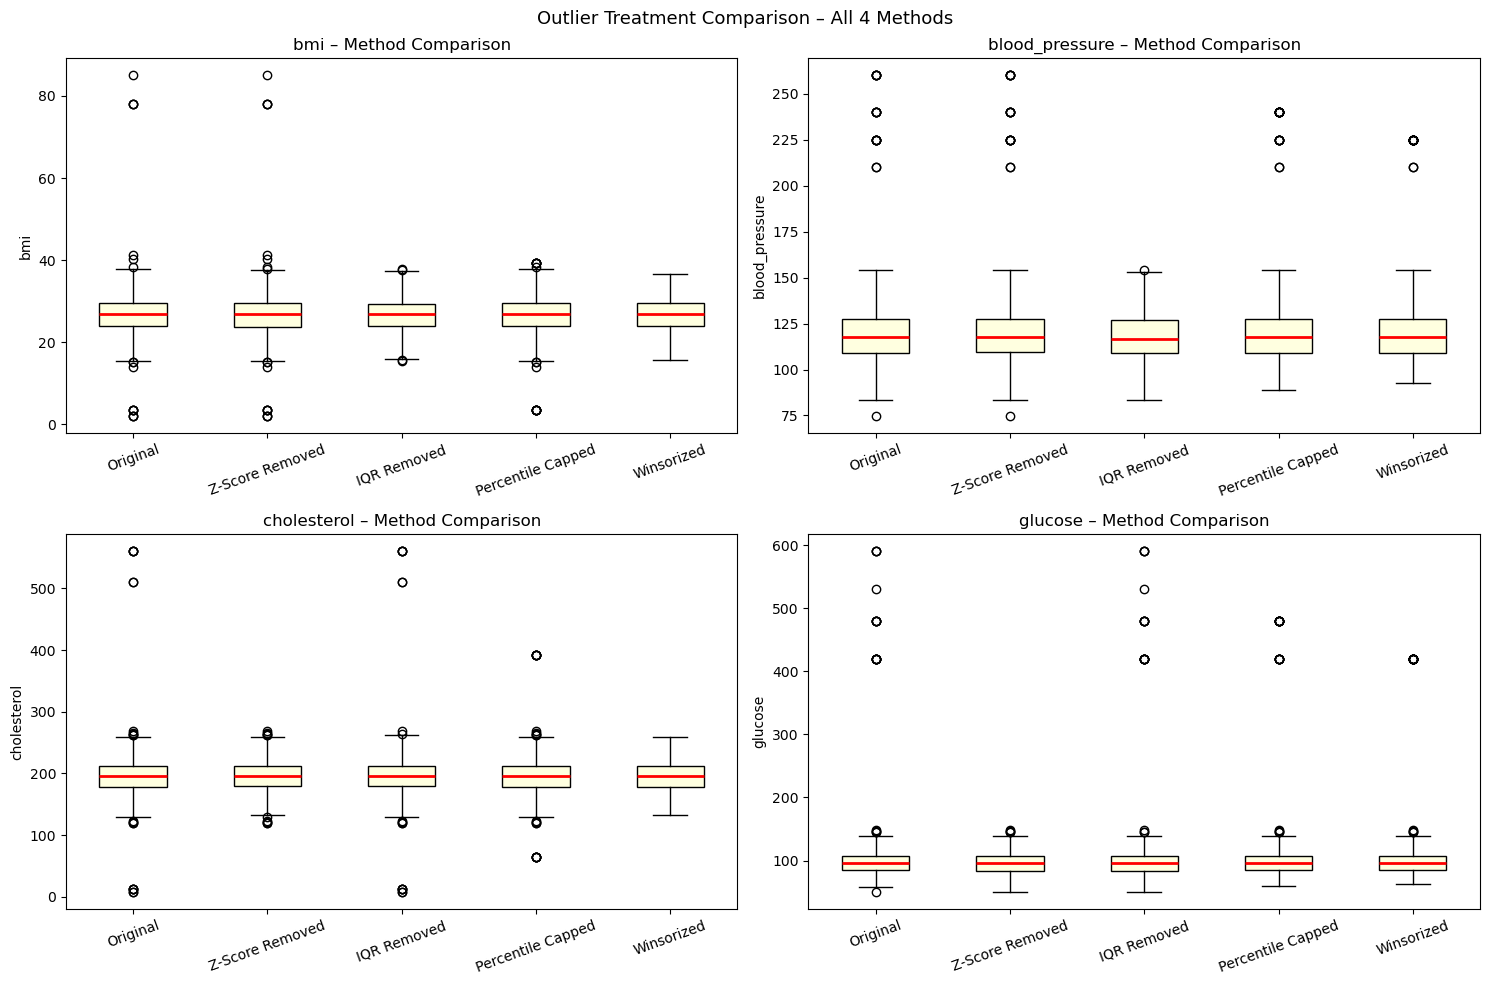

In [17]:
summary = {
    'Original':           base,
    'Z-Score Removed':    df_z,
    'IQR Removed':        df_iqr,
    'Percentile Capped':  df_pct,
    'Winsorized':         df_wins
}

print(f"{'Method':<22} {'Rows':>6}  {'BMI max':>10}  {'BP max':>8}  {'Chol max':>10}  {'Gluc max':>10}")
print("-" * 75)
for name, d in summary.items():
    print(f"{name:<22} {len(d):>6}  {d['bmi'].max():>10.2f}  {d['blood_pressure'].max():>8.1f}  {d['cholesterol'].max():>10.2f}  {d['glucose'].max():>10.2f}")

# side by side boxplots
compare_cols = ['bmi', 'blood_pressure', 'cholesterol', 'glucose']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(compare_cols):
    data   = [d[col].dropna().values for d in summary.values()]
    labels = list(summary.keys())
    axes[idx].boxplot(data, labels=labels, patch_artist=True,
                      boxprops=dict(facecolor='lightyellow'),
                      medianprops=dict(color='red', linewidth=2))
    axes[idx].set_title(f'{col} – Method Comparison')
    axes[idx].tick_params(axis='x', rotation=20)
    axes[idx].set_ylabel(col)

plt.suptitle('Outlier Treatment Comparison – All 4 Methods', fontsize=13)
plt.tight_layout()
plt.show()

---
# Part C – Final Clean Dataset

### Task 6 – Build Final Clean Dataset

In [18]:
# start from original raw data
df_final = df.copy()

# Step 1 – impute numericals with MICE
num_cols = ['age', 'bmi', 'cholesterol', 'glucose']
mice_final = IterativeImputer(max_iter=10, random_state=42)
df_final[num_cols] = mice_final.fit_transform(df_final[num_cols])

# Step 2 – impute categoricals with most frequent
for col in ['gender', 'region']:
    df_final[col] = df_final[col].fillna(df_final[col].mode()[0])

print("Missing after imputation:")
print(df_final.isnull().sum())

# Step 3 – handle outliers with winsorization (keeps all 550 rows)
treat_cols = ['bmi', 'blood_pressure', 'cholesterol', 'glucose']
for col in treat_cols:
    df_final[col] = winsorize(df_final[col], limits=[0.02, 0.02]).data
    df_final[col] = df_final[col].astype(float).round(2)

df_final['age'] = df_final['age'].round(0).astype(int)

print(f"\nFinal dataset shape: {df_final.shape}")
print()
df_final.head(10)

Missing after imputation:
patient_id        0
age               0
gender            0
region            0
bmi               0
blood_pressure    0
cholesterol       0
glucose           0
disease_risk      0
dtype: int64

Final dataset shape: (550, 9)



,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,P0001,58,Female,East,30.04,95.9,179.20,71.30,0
1,P0002,71,Female,West,22.49,112.0,206.80,83.00,1
2,P0003,48,Female,North,21.72,110.0,204.30,90.50,1
3,P0004,34,Male,West,27.12,131.7,199.00,67.90,1
4,P0005,62,Female,South,25.34,104.8,163.20,107.02,1
5,P0006,27,Male,North,30.67,108.1,196.76,106.10,0
6,P0007,80,Female,South,28.69,113.0,257.20,119.30,0
7,P0008,40,Male,West,29.00,110.5,195.20,87.90,0
8,P0009,58,Female,West,26.84,135.8,165.70,107.90,0
9,P0010,77,Male,South,26.68,103.2,196.77,62.50,1


### Final Dataset – Stats & Visuals

In [19]:
print(df_final.describe(include='all').round(2))

       patient_id     age gender region     bmi  blood_pressure  cholesterol  \
count         550  550.00    550    550  550.00          550.00       550.00   
unique        550     NaN      2      4     NaN             NaN          NaN   
top         P0550     NaN   Male  North     NaN             NaN          NaN   
freq            1     NaN    300    175     NaN             NaN          NaN   
mean          NaN   50.85    NaN    NaN   26.75          121.06       195.04   
std           NaN   17.14    NaN    NaN    4.49           22.58        26.82   
min           NaN   20.00    NaN    NaN   15.77           92.40       132.50   
25%           NaN   38.00    NaN    NaN   23.89          109.20       178.42   
50%           NaN   51.00    NaN    NaN   26.87          117.50       195.70   
75%           NaN   65.00    NaN    NaN   29.54          127.45       211.65   
max           NaN   80.00    NaN    NaN   36.59          225.00       259.30   

        glucose  disease_risk  
count  

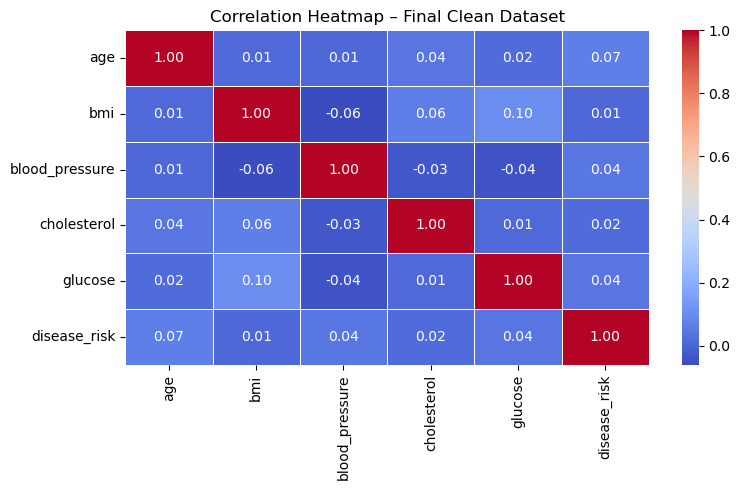

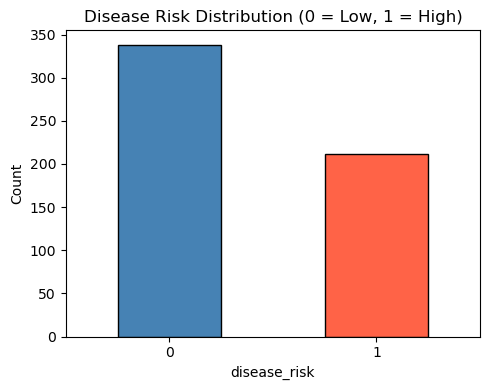

In [20]:
# correlation heatmap
plt.figure(figsize=(8, 5))
num_data = df_final.select_dtypes(include=np.number)
sns.heatmap(num_data.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap – Final Clean Dataset')
plt.tight_layout()
plt.show()

# disease risk distribution
plt.figure(figsize=(5, 4))
df_final['disease_risk'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Disease Risk Distribution (0 = Low, 1 = High)')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Save Final Dataset to CSV

In [21]:
df_final.to_csv('patient_health_records_clean.csv', index=False)
print("Saved: patient_health_records_clean.csv")
print(f"Shape: {df_final.shape}")

Saved: patient_health_records_clean.csv
Shape: (550, 9)


---
## Task 7 – Brief Report

### Which imputation method was most effective?

- **Simple Mean/Median** – Quick and easy but gets affected by outliers. Good starting point.
- **Most Frequent** – Works well for categorical columns like Gender and Region.
- **Random Sample** – Keeps the original distribution but adds some randomness.
- **KNN** – Better because it looks at similar patients to fill the gap, not just a single value.
- **MICE** – Best overall. It uses all columns together to estimate missing values. More accurate than the rest.

**Winner: MICE** – because it considers relationships between features while imputing.

---

### Which outlier method preserved data quality best?

- **Z-Score** – Removes rows where values are 3 standard deviations away. Simple but removes real patients.
- **IQR** – Uses Q1/Q3 fences. Standard approach, removes rows too.
- **Percentile Capping** – No rows removed. Just clips values at 1st and 99th percentile. Safe choice.
- **Winsorization** – Similar to percentile capping. Caps top and bottom 2%. No data loss.

**Winner: Winsorization** – No rows are deleted. All 550 patients stay. Extreme values are just capped.

---

### How did data cleaning improve the dataset?

- Reduced total missing values from ~228 to **0**
- Removed unrealistic values (BMI = 85, Glucose = 590, Cholesterol = 560)
- All 550 rows preserved
- Dataset is now ready for machine learning
